In [ ]:
import duckdb
import geopandas as gpd
import icechunk
import matplotlib.pyplot as plt
import xarray as xr
from ibicus.debias import QuantileMapping
from ibicus.utils import ecdf, iecdf

from saidownscale.bcsd_config import BCSDConfig, PipelineOptions
from saidownscale.pipeline import BCSDPipeline

# Compare ibicus implementation of 31-day windowing to hand-rolled version

## Get data

In [2]:
# Define South Africa bounds
df = duckdb.sql(
    """
    install httpfs; load httpfs;
    install spatial; load spatial;
    SELECT name, ST_AsText(geom) as geometry
    FROM ST_Read('https://carbonplan-data.s3.us-west-2.amazonaws.com/countries-50m.json')
    WHERE NAME = 'South Africa'
    """
).df()
df["geometry"] = gpd.GeoSeries.from_wkt(df["geometry"])
south_africa_geom = gpd.GeoDataFrame(df, geometry="geometry")

# Set bounds with 2-degree buffer
lon_min, lat_min, lon_max, lat_max = south_africa_geom.total_bounds
bounds = [lat_min - 2, lat_max + 2, lon_min - 2, lon_max + 2]
bounds = [round(entry, 2) for entry in bounds]

print(f"South Africa subset bounds: {bounds}")

South Africa subset bounds: [np.float64(-48.96), np.float64(-20.15), np.float64(14.45), np.float64(39.89)]


In [3]:
# Create configuration
config = BCSDConfig(
    gcm="CESM2-WACCM",
    variable="tas",
    ensemble_member="r1i1p1f1",
    scenario="SSP245",
    train_period_start=1978,
    train_period_end=2014,
    predict_period_start=2015,
    predict_period_end=2100,
    subset_bounds=tuple(bounds),
    debias_approach="nonparametric",
)

# Operational settings (storage paths, environment, runtime flags).
# These live in PipelineOptions and do not affect the computation or cache key.
options = PipelineOptions(
    scratch_dir="s3://carbonplan-scratch/srm/bcsd-cache",
    output_dir="s3://carbonplan-scratch/srm/outputs",
    environment="qa",  # Use 'qa' for testing
    branch="v5.6_nonparametric",
    verbose=True,
    save_intermediate=True,
)

print(f"Run ID: {config.run_id}")
print(f"Config hash: {config.config_hash}")
print(f"Detrend data: {config.variable_config.detrend_data}")

Run ID: CESM2-WACCM_tas_r1i1p1f1_SSP245_subset
Config hash: 3a1839139748
Detrend data: True


In [4]:
# Initialize pipeline
pipeline = BCSDPipeline(config, options)

# Run all three stages
print("Stage 1: Prepare observations (regrid ERA5 to GCM grid)")
obs_path_nonparametric = pipeline.prepare_observations(force=False)
print(f"✓ Observations cached at: {obs_path_nonparametric}\n")

print("Stage 2: Fit historical (debias and downscale historical period)")
hist_path_nonparametric = pipeline.fit_historical(force=False)
print(f"✓ Historical cached at: {hist_path_nonparametric}\n")

print("Stage 3: Transform scenario (debias and downscale future)")
scenario_path_nonparametric = pipeline.transform_scenario(force=False)
print(f"✓ Scenario output at: {scenario_path_nonparametric}")

Stage 1: Prepare observations (regrid ERA5 to GCM grid)
✓ Observations cached at: s3://carbonplan-scratch/srm/bcsd-cache/qa/v5.6_nonparametric/obs/CESM2-WACCM_tas_lat-48.96to-20.15_lon14.45to39.89_obs_regridded.icechunk

Stage 2: Fit historical (debias and downscale historical period)
✓ Historical cached at: s3://carbonplan-scratch/srm/outputs/qa/v5.6_nonparametric/historical/CESM2-WACCM_tas_r1i1p1f1_lat-48.96to-20.15_lon14.45to39.89_historical.icechunk

Stage 3: Transform scenario (debias and downscale future)
✓ Scenario output at: s3://carbonplan-scratch/srm/outputs/qa/v5.6_nonparametric/ssp245/CESM2-WACCM_tas_r1i1p1f1_lat-48.96to-20.15_lon14.45to39.89_ssp245.icechunk


In [5]:
# Also load the raw GCM data for comparison
from saidownscale.downscaling_utils import get_experiment, get_obs, subset_space

# Load fine-resolution observations
obs_fine = get_obs(var=config.variable)
obs_fine = subset_space(obs_fine, bounds)
obs_fine = obs_fine.sel(time=slice("1978", "2014"))

# Load coarse GCM data
model_hist_raw = get_experiment(gcm=config.gcm, scenario="Historical", var=config.variable)
if "ensemble_member" in model_hist_raw.dims:
    model_hist_raw = model_hist_raw.sel(ensemble_member=config.ensemble_member)
model_hist_raw = subset_space(model_hist_raw, bounds)
model_hist_raw = model_hist_raw.sel(time=slice("1978", "2014"))

model_scenario_raw = get_experiment(gcm=config.gcm, scenario=config.scenario, var=config.variable)
model_scenario_raw = model_scenario_raw.sel(ensemble_member=config.ensemble_member)
model_scenario_raw = subset_space(model_scenario_raw, bounds)
model_scenario_raw = model_scenario_raw.sel(time=slice("2015", "2100"))

print("Loaded raw GCM data for comparison")

Loaded raw GCM data for comparison


In [6]:
# import icechunk
bucket = "carbonplan-scratch"
prefix_nonparametric = "srm/bcsd-cache/qa/6_nonparametric_hybrid/obs/CESM2-WACCM_tas_lat-48.96to-20.15_lon14.45to39.89_obs_regridded.icechunk"


def open_icechunk(path, prefix=prefix_nonparametric):
    bucket, prefix = path.replace("s3://", "").split("/", 1)
    storage = icechunk.s3_storage(bucket=bucket, prefix=prefix)
    repo = icechunk.Repository.open(storage)
    session = repo.readonly_session("main")

    ds = xr.open_dataset(session.store, engine="zarr", chunks={})
    return ds

In [7]:
obs_coarse_path = "s3://carbonplan-scratch/srm/bcsd-cache/qa/v5.6_nonparametric/obs/CESM2-WACCM_tas_lat-48.96to-20.15_lon14.45to39.89_obs_regridded.icechunk"
obs_coarse = open_icechunk(obs_coarse_path)[config.variable]

In [8]:
detrended_scenario_path = "s3://carbonplan-scratch/srm/bcsd-cache/qa/v5.6_nonparametric/ssp245/CESM2-WACCM_tas_r1i1p1f1_lat-48.96to-20.15_lon14.45to39.89_ssp245_detrended.icechunk"
detrended_scenario = open_icechunk(detrended_scenario_path)[config.variable]

In [9]:
debiased_scenario_coarse_nonparametric_path = "s3://carbonplan-scratch/srm/bcsd-cache/qa/v5.6_nonparametric/ssp245/CESM2-WACCM_tas_r1i1p1f1_lat-48.96to-20.15_lon14.45to39.89_ssp245_debiased_coarse.icechunk"
debiased_scenario_coarse_nonparametric = open_icechunk(debiased_scenario_coarse_nonparametric_path)[
    config.variable
]

In [10]:
debiased_hist_coarse_nonparametric_path = "s3://carbonplan-scratch/srm/bcsd-cache/qa/v5.6_nonparametric/ssp245/CESM2-WACCM_tas_r1i1p1f1_lat-48.96to-20.15_lon14.45to39.89_ssp245_debiased_coarse.icechunk"
debiased_hist_coarse_nonparametric = open_icechunk(debiased_hist_coarse_nonparametric_path)[
    config.variable
]

In [11]:
# Get Cape Town coordinates
cities = gpd.read_file(
    "https://naciscdn.org/naturalearth/110m/cultural/ne_110m_populated_places_simple.zip",
    columns=["name", "sov0name", "geometry"],
)
sa_cities = cities[cities["sov0name"] == "South Africa"]
cape_town_lon = float(sa_cities[sa_cities["name"] == "Cape Town"].geometry.x.item())
cape_town_lat = float(sa_cities[sa_cities["name"] == "Cape Town"].geometry.y.item())

print(f"Cape Town: ({cape_town_lat:.2f}°, {cape_town_lon:.2f}°)")

Cape Town: (-33.92°, 18.43°)


## Do the two calculations

In [12]:
obs_coarse_ct = obs_coarse.sel(
    lat=cape_town_lat, lon=cape_town_lon, method="nearest", drop=False
).compute()
model_hist_raw_ct = model_hist_raw.sel(
    lat=cape_town_lat, lon=cape_town_lon, method="nearest", drop=False
).compute()
detrended_scenario_ct = detrended_scenario.sel(
    lat=cape_town_lat, lon=cape_town_lon, method="nearest", drop=False
).compute()
debiased_hist_ct = debiased_hist_coarse_nonparametric.sel(
    lat=cape_town_lat, lon=cape_town_lon, method="nearest", drop=False
).compute()
debiased_scenario_ct = debiased_scenario_coarse_nonparametric.sel(
    lat=cape_town_lat, lon=cape_town_lon, method="nearest", drop=False
).compute()

In [13]:
model_hist_raw_subset = model_hist_raw  # .where(model_hist_raw['time.year']<1980, drop=True)
obs_coarse_subset = obs_coarse  # .where(obs_coarse['time.year']<1980, drop=True)
detrended_scenario_subset = (
    detrended_scenario  # .where(detrended_scenario['time.year']==1978, drop=True)
)

model_hist_raw_ct_subset = model_hist_raw_ct  # .where(model_hist_raw['time.year']<1980, drop=True)
obs_coarse_ct_subset = obs_coarse_ct  # .where(obs_coarse['time.year']<1980, drop=True)
detrended_scenario_ct_subset = (
    detrended_scenario_ct  # .where(detrended_scenario['time.year']==1978, drop=True)
)

### ibicus implementation

In [14]:
debiaser = QuantileMapping.from_variable(
    variable="tas",
    mapping_type="nonparametric",
    detrending="no_detrending",
    running_window_mode=True,
    running_window_length=31,
    running_window_step_length=1,
    running_window_mode_over_years_of_cm_future=False,
)

In [15]:
scenario_debiased_np = debiaser.apply(
    obs=obs_coarse_subset.values,
    cm_hist=model_hist_raw_subset.values,
    cm_future=detrended_scenario_subset.values,
    time_obs=obs_coarse_subset["time"].values,
    time_cm_hist=model_hist_raw_subset["time"].values,
    time_cm_future=detrended_scenario_subset["time"].values,
    parallel=False,
    progressbar=True,
)

100%|██████████| 620/620 [02:34<00:00,  4.01it/s]


In [16]:
hist_debiased_np = debiaser.apply(
    obs=obs_coarse_subset.values,
    cm_hist=model_hist_raw_subset.values,
    cm_future=model_hist_raw_subset.values,
    time_obs=obs_coarse_subset["time"].values,
    time_cm_hist=model_hist_raw_subset["time"].values,
    time_cm_future=model_hist_raw_subset["time"].values,
    parallel=False,
    progressbar=True,
)

100%|██████████| 620/620 [01:47<00:00,  5.76it/s]


In [17]:
ibicus_scenario_debiased = xr.DataArray(
    data=scenario_debiased_np,
    coords={
        "lat": detrended_scenario["lat"],
        "lon": detrended_scenario["lon"],
        "time": detrended_scenario["time"],
    },
    dims=["time", "lat", "lon"],
)

In [18]:
ibicus_hist_debiased = xr.DataArray(
    data=hist_debiased_np,
    coords={
        "lat": model_hist_raw_subset["lat"],
        "lon": model_hist_raw_subset["lon"],
        "time": model_hist_raw_subset["time"],
    },
    dims=["time", "lat", "lon"],
)

In [19]:
ibicus_hist_debiased_ct = ibicus_hist_debiased.sel(
    lat=cape_town_lat, lon=cape_town_lon, method="nearest", drop=False
).compute()
ibicus_scenario_debiased_ct = ibicus_scenario_debiased.sel(
    lat=cape_town_lat, lon=cape_town_lon, method="nearest", drop=False
).compute()

### handrolled-version

In [20]:
idoy = 20

model_hist_raw_ct_subset_windowed = model_hist_raw_ct_subset.where(
    (model_hist_raw_ct_subset["time.dayofyear"] >= idoy - 15)
    & (model_hist_raw_ct_subset["time.dayofyear"] <= idoy + 15),
    drop=True,
)
obs_coarse_ct_subset_windowed = obs_coarse_ct_subset.where(
    (obs_coarse_ct_subset["time.dayofyear"] >= idoy - 15)
    & (obs_coarse_ct_subset["time.dayofyear"] <= idoy + 15),
    drop=True,
)
detrended_scenario_ct_subset_windowed = detrended_scenario_ct_subset.where(
    (detrended_scenario_ct_subset["time.dayofyear"] >= idoy - 15)
    & (detrended_scenario_ct_subset["time.dayofyear"] <= idoy + 15),
    drop=True,
)

In [21]:
ecdf_method = "step_function"
iecdf_method = "inverted_cdf"

x = model_hist_raw_ct_subset_windowed
y = obs_coarse_ct_subset_windowed
vals = model_hist_raw_ct_subset_windowed

lookup_ecdf = ecdf(x, vals, method=ecdf_method)
mapped_val_hist = iecdf(y, lookup_ecdf, method=iecdf_method)

In [22]:
x = model_hist_raw_ct_subset_windowed
y = obs_coarse_ct_subset_windowed
vals = detrended_scenario_ct_subset_windowed

lookup_ecdf = ecdf(x, vals, method=ecdf_method)
mapped_val_scenario = iecdf(y, lookup_ecdf, method=iecdf_method)

In [23]:
handrolled_result_hist = mapped_val_hist[
    model_hist_raw_ct_subset_windowed["time.dayofyear"] == idoy
]
ibicus_result_hist = ibicus_hist_debiased_ct.where(
    ibicus_hist_debiased_ct["time.dayofyear"] == idoy, drop=True
)

handrolled_result_scenario = mapped_val_scenario[
    detrended_scenario_ct_subset_windowed["time.dayofyear"] == idoy
]
ibicus_result_scenario = ibicus_scenario_debiased_ct.where(
    ibicus_scenario_debiased_ct["time.dayofyear"] == idoy, drop=True
)

In [24]:
print(handrolled_result_hist)
print(ibicus_result_hist.values)

[299.90475 295.21902 290.66742 296.60596 291.80457 295.16687 295.94547
 294.76752 293.5462  293.2848  291.59073 292.47247 293.63916 294.217
 295.76297 295.3761  291.7694  292.2412  298.8247  295.46378 294.03775
 296.7977  291.91388 292.57196 298.78754 294.62997 297.0283  295.7966
 293.32306 293.088   296.1936  297.2806  293.41376 293.5763  296.7726
 300.04532 292.548  ]
[299.90475 295.21902 290.66742 296.60596 291.80457 295.16687 295.94547
 294.76752 293.5462  293.2848  291.59073 292.47247 293.63916 294.217
 295.76297 295.3761  291.7694  292.2412  298.8247  295.46378 294.03775
 296.7977  291.91388 292.57196 298.78754 294.62997 297.0283  295.7966
 293.32306 293.088   296.1936  297.2806  293.41376 293.5763  296.7726
 300.04532 292.548  ]


## Make figures comparing results

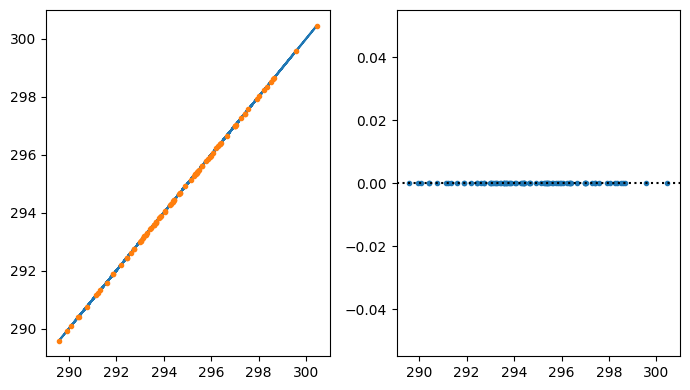

In [25]:
plt.figure(figsize=(7, 4))
plt.subplot(1, 2, 1)
plt.plot(ibicus_result_scenario, ibicus_result_scenario, "-")
plt.plot(ibicus_result_scenario, handrolled_result_scenario, ".")
plt.subplot(1, 2, 2)
plt.plot(ibicus_result_scenario, ibicus_result_scenario - handrolled_result_scenario, ".")
plt.axhline(y=0, linestyle=":", color="k")
plt.tight_layout()

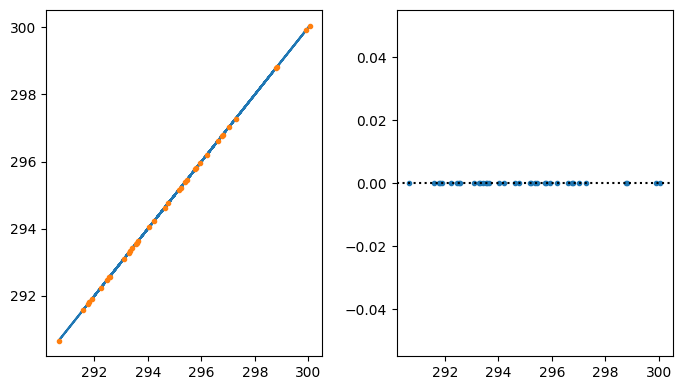

In [26]:
plt.figure(figsize=(7, 4))
plt.subplot(1, 2, 1)
plt.plot(ibicus_result_hist, ibicus_result_hist, "-")
plt.plot(ibicus_result_hist, handrolled_result_hist, ".")
plt.subplot(1, 2, 2)
plt.plot(ibicus_result_hist, ibicus_result_hist - handrolled_result_hist, ".")
plt.axhline(y=0, linestyle=":", color="k")
plt.tight_layout()

# Compare results with and without windowing to see impact

In [27]:
import xarray as xr


def load_data(k):
    storage = icechunk.s3_storage(
        bucket="carbonplan-scratch",
        prefix=f"srm/outputs/{k}/qa/v1/ssp245/CESM2-WACCM_tas_r1i1p1f1_lat-35.0to-22.0_lon16.0to33.0_ssp245.icechunk",
        from_env=True,
    )
    repo = icechunk.Repository.open(storage)
    session = repo.readonly_session(branch="main")
    ds = xr.open_dataset(session.store, engine="zarr", chunks="auto")
    return ds


window = load_data("window")
no_window = load_data("no-window")

In [30]:
diff_mean = window["tas"].mean(dim="time") - no_window["tas"].mean(dim="time")

In [32]:
diff_hot_extreme = window["tas"].quantile(0.99, dim="time") - no_window["tas"].quantile(
    0.99, dim="time"
)

In [33]:
diff_cold_extreme = window["tas"].quantile(0.01, dim="time") - no_window["tas"].quantile(
    0.01, dim="time"
)

In [ ]:
(no_window["tas"] - window["tas"]).quantile([0.1, 0.5, 0.9]).compute()

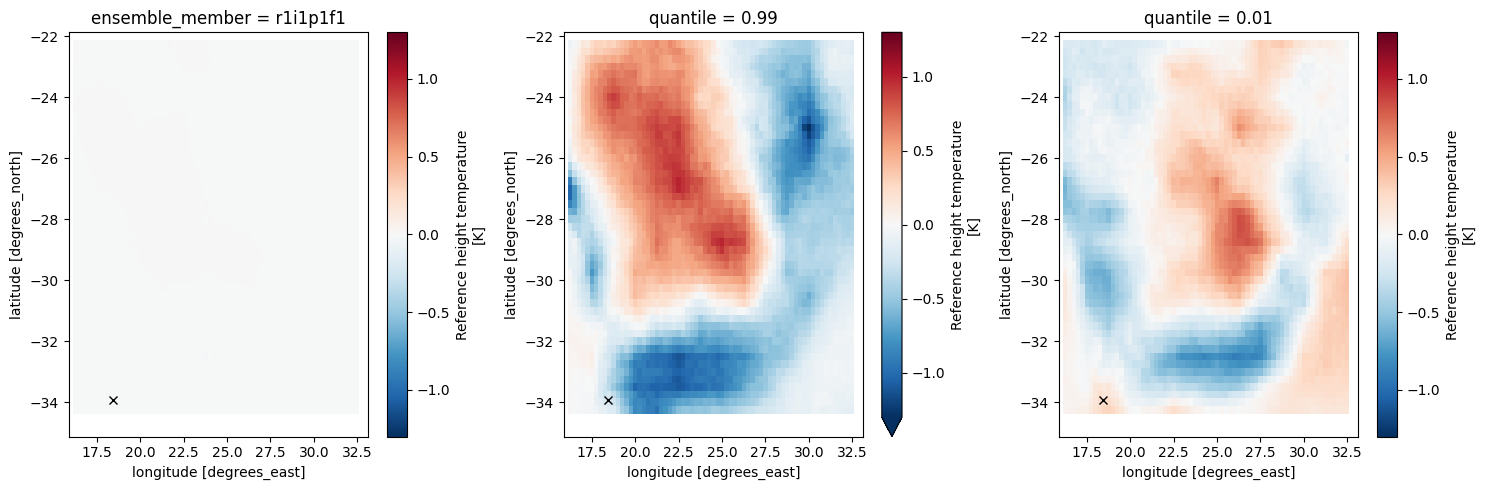

In [60]:
plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
diff_mean.plot(vmax=1.3)
plt.plot([cape_town_lon], [cape_town_lat], "xk")
plt.subplot(1, 3, 2)
diff_hot_extreme.plot(vmax=1.3)
plt.plot([cape_town_lon], [cape_town_lat], "xk")
plt.subplot(1, 3, 3)
diff_cold_extreme.plot(vmax=1.3)
plt.plot([cape_town_lon], [cape_town_lat], "xk")
plt.tight_layout()

In [37]:
window_ct = (
    window["tas"].sel(lat=cape_town_lat, lon=cape_town_lon, method="nearest", drop=False).compute()
)
no_window_ct = (
    no_window["tas"]
    .sel(lat=cape_town_lat, lon=cape_town_lon, method="nearest", drop=False)
    .compute()
)

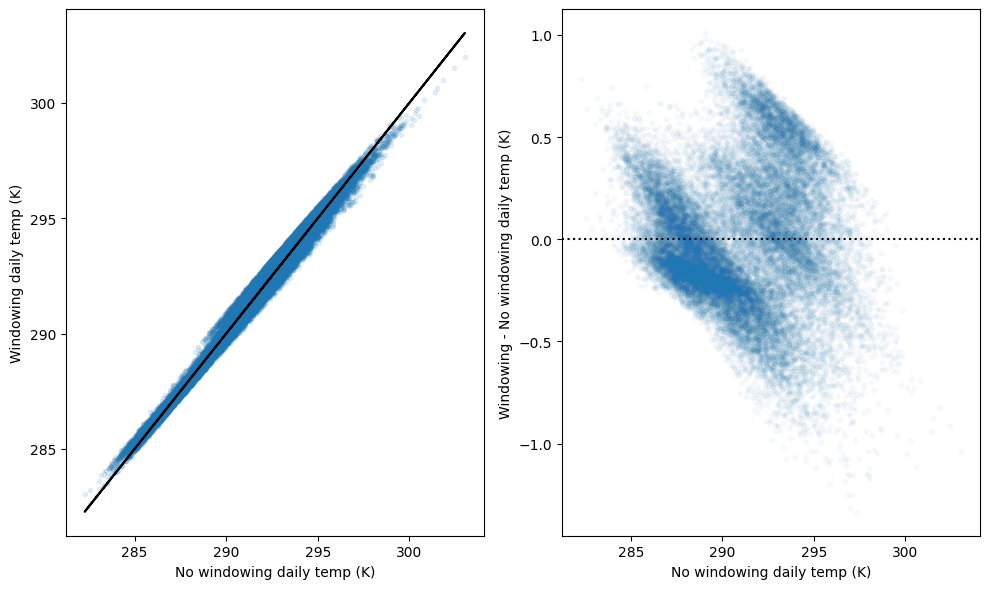

In [67]:
plt.figure(figsize=(10, 6))
plt.subplot(1, 2, 1)
plt.plot(no_window_ct, window_ct, ".", alpha=0.1)
plt.plot(no_window_ct, no_window_ct, "-k")
plt.xlabel("No windowing daily temp (K)")
plt.ylabel("Windowing daily temp (K)")
plt.subplot(1, 2, 2)
plt.plot(no_window_ct, window_ct - no_window_ct, ".", alpha=0.03)
plt.axhline(y=0, linestyle=":", color="k")
plt.xlabel("No windowing daily temp (K)")
plt.ylabel("Windowing - No windowing daily temp (K)")
plt.tight_layout()

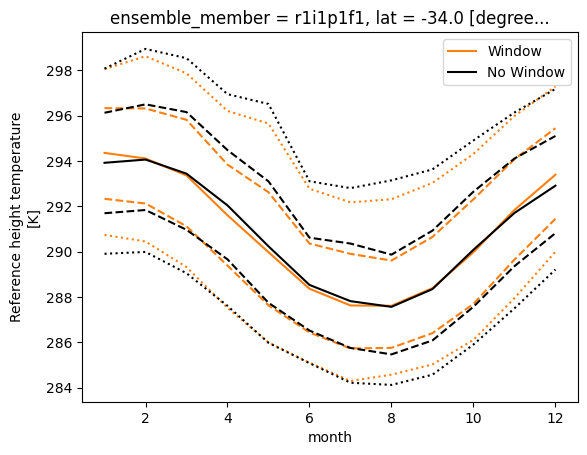

In [58]:
window_ct.groupby("time.month").mean(dim="time").plot(color="C1", linestyle="-", label="Window")
window_ct.groupby("time.month").quantile(0.1, dim="time").plot(color="C1", linestyle="--")
window_ct.groupby("time.month").quantile(0.9, dim="time").plot(color="C1", linestyle="--")
window_ct.groupby("time.month").quantile(0.01, dim="time").plot(color="C1", linestyle=":")
window_ct.groupby("time.month").quantile(0.99, dim="time").plot(color="C1", linestyle=":")
no_window_ct.groupby("time.month").mean(dim="time").plot(
    color="k", linestyle="-", label="No Window"
)
no_window_ct.groupby("time.month").quantile(0.1, dim="time").plot(color="k", linestyle="--")
no_window_ct.groupby("time.month").quantile(0.9, dim="time").plot(color="k", linestyle="--")
no_window_ct.groupby("time.month").quantile(0.01, dim="time").plot(color="k", linestyle=":")
no_window_ct.groupby("time.month").quantile(0.99, dim="time").plot(color="k", linestyle=":")
plt.legend()